In [2]:
import re
import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix

from analysis_shared_functions import bulk_vs_singlecell_matrix_viz, all_samples_matrix_viz

In [3]:
DATA_PATH = "../../data/output_data/"
FIGURES_PATH = "../../data/figures/"
tool = "CrosscheckFingerprints"
dataset = "low_grade_glioma"
pseudobulk = True
ncells = 100000
rd = 1

# Data munging

## Similarity matrix

In [4]:
if pseudobulk:
    fingerprints_df = pd.read_csv(
        DATA_PATH + 
        f"2a_fingerprints/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/crosscheck_metrics.txt", 
        sep="\t", skiprows=6, header=0
    )
else:
    fingerprints_df = pd.read_csv(
        DATA_PATH + 
        f"2a_fingerprints/{dataset}/real_data/ncells_null/read_depth_{rd}/crosscheck_metrics.txt", 
        sep="\t", skiprows=6, header=0
    )
fingerprints_df = fingerprints_df[["LEFT_SAMPLE", "RIGHT_SAMPLE", "LOD_SCORE", "RESULT"]]

In [5]:
if dataset == "hgsoc":
    regex_exp = r"[a-zA-Z0-9]{32}_"
elif dataset == "low_grade_glioma":
    regex_exp = r"^GSM[0-9]{7}_"

fingerprints_dict = {
    x: 
    re.sub(regex_exp, "", x.replace(".bam", "").replace("ds.", ""))
    
    for x in list(set(fingerprints_df["LEFT_SAMPLE"]) | set(fingerprints_df["RIGHT_SAMPLE"]))
}
fingerprints_df["LEFT_SAMPLE"] = fingerprints_df["LEFT_SAMPLE"].map(fingerprints_dict)
fingerprints_df["RIGHT_SAMPLE"] = fingerprints_df["RIGHT_SAMPLE"].map(fingerprints_dict)

In [6]:
fingerprints_df.head()

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,pseudobulk_GSM7326896_ncells_100000_2,pseudobulk_GSM7326896_ncells_100000_2,8.126441,EXPECTED_MATCH
1,pseudobulk_GSM7326896_ncells_100000_2,pseudobulk_GSM7326884_ncells_100000_2,0.542409,UNEXPECTED_MATCH
2,pseudobulk_GSM7326896_ncells_100000_2,pseudobulk_GSM7326894_ncells_100000_1,0.645570,UNEXPECTED_MATCH
3,pseudobulk_GSM7326896_ncells_100000_2,pseudobulk_GSM7326899_ncells_100000_3,0.586132,UNEXPECTED_MATCH
4,pseudobulk_GSM7326896_ncells_100000_2,pseudobulk_GSM7326902_ncells_100000_2,-1.559629,EXPECTED_MISMATCH


In [14]:
def long_df_to_matrix_fingerprints(df, metric="LOD_SCORE"):
    # Use pivot_table for much faster matrix creation
    matrix = df.pivot_table(
        index='LEFT_SAMPLE',
        columns='RIGHT_SAMPLE', 
        values=metric,
        aggfunc='first'  # Use first value if duplicates exist
    )
    
    # Get all unique samples to create a square matrix
    all_samples = sorted(set(df['LEFT_SAMPLE']) | set(df['RIGHT_SAMPLE']))
    matrix = matrix.reindex(index=all_samples, columns=all_samples)
    
    # Make matrix symmetric by filling NaN values
    matrix = matrix.combine_first(matrix.T)
    
    # Order rows and columns by bulk modality and sample ID
    matrix = matrix.sort_index(
        key=lambda x: x.str.split('_').str[0]).sort_index(key=lambda x: x.str.split('_', n=1).str[1]
    )
    matrix = matrix.reindex(
        sorted(
            sorted(
                matrix.columns,
                key=lambda x: x.split('_', 1)[0]
            ),
            key=lambda x: x.split('_', 1)[1]
        )
    )
    matrix = matrix[matrix.index]

    return matrix

In [8]:
fingerprints_matrix = long_df_to_matrix_fingerprints(fingerprints_df)

In [9]:
fingerprints_matrix.head()

,pseudobulk_GSM7326880_ncells_100000_1,pseudobulk_GSM7326880_ncells_100000_2,pseudobulk_GSM7326880_ncells_100000_3,pseudobulk_GSM7326881_ncells_100000_1,pseudobulk_GSM7326881_ncells_100000_2,pseudobulk_GSM7326881_ncells_100000_3,pseudobulk_GSM7326883_ncells_100000_1,pseudobulk_GSM7326883_ncells_100000_2,pseudobulk_GSM7326883_ncells_100000_3,pseudobulk_GSM7326884_ncells_100000_1,...,pseudobulk_GSM7326901_ncells_100000_3,pseudobulk_GSM7326902_ncells_100000_1,pseudobulk_GSM7326902_ncells_100000_2,pseudobulk_GSM7326902_ncells_100000_3,pseudobulk_GSM7326903_ncells_100000_1,pseudobulk_GSM7326903_ncells_100000_2,pseudobulk_GSM7326903_ncells_100000_3,pseudobulk_GSM7326905_ncells_100000_1,pseudobulk_GSM7326905_ncells_100000_2,pseudobulk_GSM7326905_ncells_100000_3
LEFT_SAMPLE,,,,,,,,,,,,,,,,,,,,,
pseudobulk_GSM7326880_ncells_100000_1,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
pseudobulk_GSM7326880_ncells_100000_2,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
pseudobulk_GSM7326880_ncells_100000_3,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
pseudobulk_GSM7326881_ncells_100000_1,0.0,0.0,0.0,0.144183,0.144183,0.144183,0.0,0.0,0.0,0.0,...,0.0,0.146396,0.146078,0.141676,0.0,0.0,0.0,0.146556,0.146556,0.146556
pseudobulk_GSM7326881_ncells_100000_2,0.0,0.0,0.0,0.144183,0.144183,0.144183,0.0,0.0,0.0,0.0,...,0.0,0.146396,0.146078,0.141676,0.0,0.0,0.0,0.146556,0.146556,0.146556


In [10]:
fingerprints_matrix.shape

(66, 66)

## Sample matches

In [40]:
# Create a mapping for CrosscheckFingerprints results to binary values
result_mapping = {
    "EXPECTED_MATCH": 1,
    "UNEXPECTED_MATCH": 1,  
    "EXPECTED_MISMATCH": 0,
    "UNEXPECTED_MISMATCH": 0,
    "INCONCLUSIVE": 0
}

inferred_matches = long_df_to_matrix_fingerprints(fingerprints_df, "RESULT").replace(result_mapping)

In [41]:
inferred_matches.head()

,pseudobulk_GSM7326880_ncells_100000_1,pseudobulk_GSM7326880_ncells_100000_2,pseudobulk_GSM7326880_ncells_100000_3,pseudobulk_GSM7326881_ncells_100000_1,pseudobulk_GSM7326881_ncells_100000_2,pseudobulk_GSM7326881_ncells_100000_3,pseudobulk_GSM7326883_ncells_100000_1,pseudobulk_GSM7326883_ncells_100000_2,pseudobulk_GSM7326883_ncells_100000_3,pseudobulk_GSM7326884_ncells_100000_1,...,pseudobulk_GSM7326901_ncells_100000_3,pseudobulk_GSM7326902_ncells_100000_1,pseudobulk_GSM7326902_ncells_100000_2,pseudobulk_GSM7326902_ncells_100000_3,pseudobulk_GSM7326903_ncells_100000_1,pseudobulk_GSM7326903_ncells_100000_2,pseudobulk_GSM7326903_ncells_100000_3,pseudobulk_GSM7326905_ncells_100000_1,pseudobulk_GSM7326905_ncells_100000_2,pseudobulk_GSM7326905_ncells_100000_3
LEFT_SAMPLE,,,,,,,,,,,,,,,,,,,,,
pseudobulk_GSM7326880_ncells_100000_1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pseudobulk_GSM7326880_ncells_100000_2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pseudobulk_GSM7326880_ncells_100000_3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pseudobulk_GSM7326881_ncells_100000_1,0,0,0,1,1,1,0,0,0,0,...,0,1,1,1,0,0,0,1,1,1
pseudobulk_GSM7326881_ncells_100000_2,0,0,0,1,1,1,0,0,0,0,...,0,1,1,1,0,0,0,1,1,1


# Real data viz & analysis

In [ ]:
bulk_vs_singlecell_matrix_viz(
    fingerprints_matrix,
    pseudobulk=pseudobulk,
    tool=tool,
    dataset=dataset,
    ncells=ncells,
    rd=rd,
    save_fig=False
)

## Comparison with expected matches

In [ ]:
expected_matches_df = pd.read_csv(
    DATA_PATH + f"../metadata/sample_matches/sample_matches_{dataset}.csv"
).dropna(how="all", axis=1).dropna(how="any")

# Pseudobulk viz & analysis

In [11]:
# Filter CrosscheckFingerprints matrix to only samples ending in _1 in rows and samples ending in _2 in columns
pseudobulk_1 = "_1"
pseudobulk_2 = "_2"
pseudobulk_regex = r"_[1-3]{1}$"
fingerprints_matrix_filtered = fingerprints_matrix.loc[
    [idx for idx in fingerprints_matrix.index if idx.endswith(pseudobulk_1)],
    [col for col in fingerprints_matrix.columns if col.endswith(pseudobulk_2)]
]

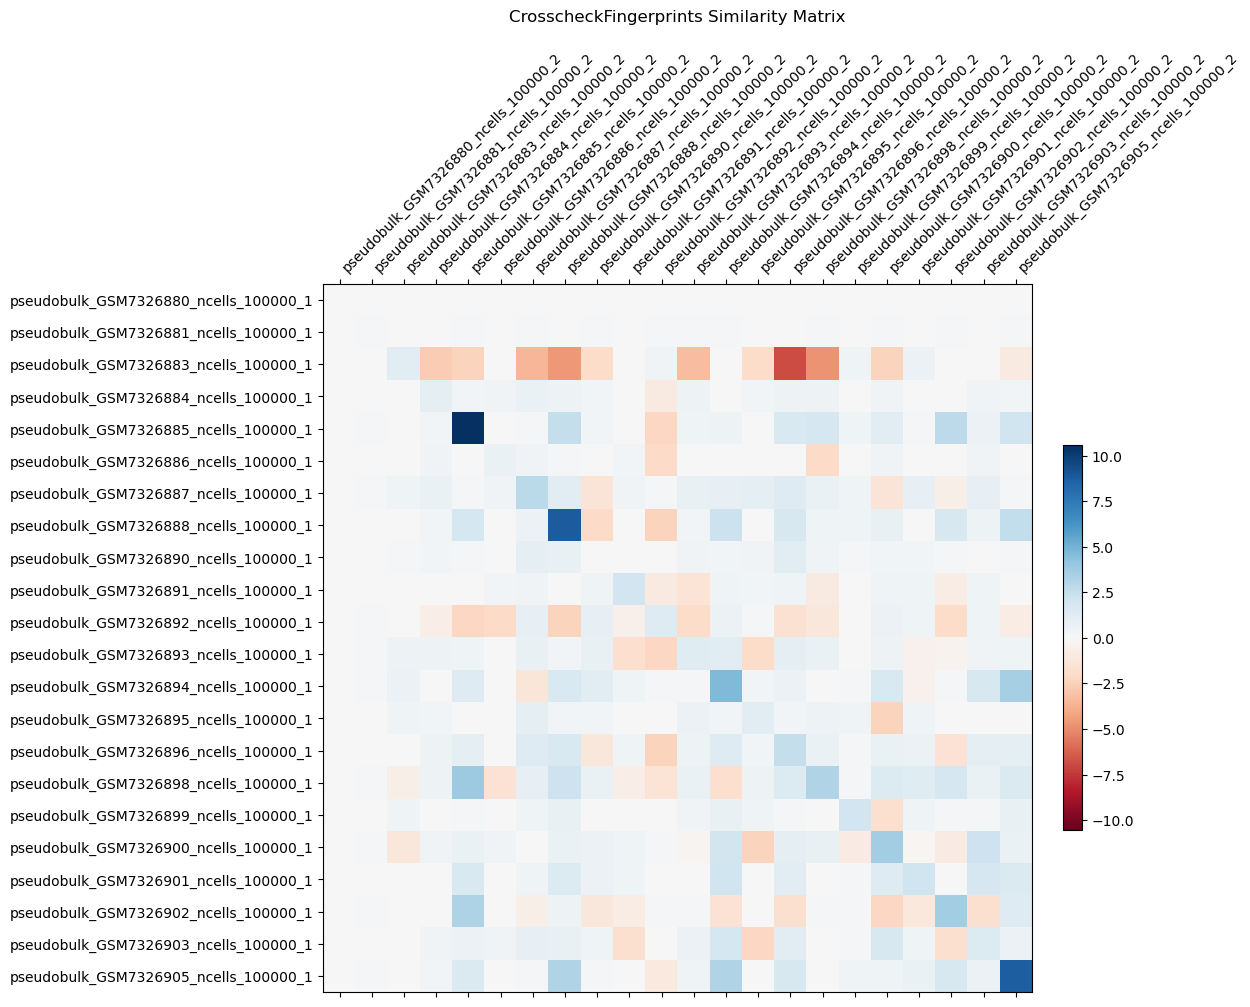

In [12]:
all_samples_matrix_viz(
    fingerprints_matrix_filtered, 
    pseudobulk=pseudobulk, 
    tool=tool, 
    dataset=dataset, 
    ncells=ncells, 
    rd=rd, 
    save_fig=False
)

## Detailed accuracy metrics

In [ ]:
# Create inferred_matches matrix for submatrix 
inferred_matches_submatrix = inferred_matches.loc[
    [idx for idx in inferred_matches.index if idx.endswith(pseudobulk_1)],
    [col for col in inferred_matches.columns if col.endswith(pseudobulk_2)]
]
inferred_matches_submatrix.columns = pd.Index(inferred_matches_submatrix.columns, name="RIGHT_SAMPLE")

In [43]:
inferred_matches_submatrix.head()

RIGHT_SAMPLE,pseudobulk_GSM7326880_ncells_100000_2,pseudobulk_GSM7326881_ncells_100000_2,pseudobulk_GSM7326883_ncells_100000_2,pseudobulk_GSM7326884_ncells_100000_2,pseudobulk_GSM7326885_ncells_100000_2,pseudobulk_GSM7326886_ncells_100000_2,pseudobulk_GSM7326887_ncells_100000_2,pseudobulk_GSM7326888_ncells_100000_2,pseudobulk_GSM7326890_ncells_100000_2,pseudobulk_GSM7326891_ncells_100000_2,...,pseudobulk_GSM7326894_ncells_100000_2,pseudobulk_GSM7326895_ncells_100000_2,pseudobulk_GSM7326896_ncells_100000_2,pseudobulk_GSM7326898_ncells_100000_2,pseudobulk_GSM7326899_ncells_100000_2,pseudobulk_GSM7326900_ncells_100000_2,pseudobulk_GSM7326901_ncells_100000_2,pseudobulk_GSM7326902_ncells_100000_2,pseudobulk_GSM7326903_ncells_100000_2,pseudobulk_GSM7326905_ncells_100000_2
LEFT_SAMPLE,,,,,,,,,,,,,,,,,,,,,
pseudobulk_GSM7326880_ncells_100000_1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pseudobulk_GSM7326881_ncells_100000_1,0,1,0,0,1,0,1,0,1,0,...,1,0,0,1,0,1,0,1,0,1
pseudobulk_GSM7326883_ncells_100000_1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
pseudobulk_GSM7326884_ncells_100000_1,0,0,0,1,1,1,1,1,1,0,...,0,1,1,1,0,1,0,0,1,1
pseudobulk_GSM7326885_ncells_100000_1,0,1,0,1,1,0,1,1,1,0,...,1,0,1,1,1,1,1,1,1,1


In [44]:
# Create true_matches matrix for submatrix 
# Matches on the diagonal (1), the rest non-matches (0)
true_matches = pd.DataFrame(
    np.identity(len(inferred_matches_submatrix)),
    index=pd.Index(inferred_matches_submatrix.index, name="pseudobulk_1"), 
    columns=pd.Index(inferred_matches_submatrix.columns, name="pseudobulk_2"),
    )

In [ ]:
# Melt matrices into long form 
true_matches_long = true_matches.stack().rename("match").reset_index().set_index(["pseudobulk_1", "pseudobulk_2"])
inferred_matches_long = inferred_matches_submatrix.stack().rename("match").reset_index().set_index(["LEFT_SAMPLE", "RIGHT_SAMPLE"])

inferred_matches_long["match"] = inferred_matches_long["match"].astype(float)

In [51]:
# Calculate confusion matrix
tn, fp, fn, tp = confusion_matrix(true_matches_long, inferred_matches_long).ravel().tolist()

In [52]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
tpr = tp / (tp + fn)
tnr = tn / (tn + fp)
balanced_accuracy = (tpr + tnr) / 2
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

print(f"Accuracy = {accuracy:.2f}")
print(f"Balanced accuracy = {balanced_accuracy:.2f}")
print(f"Precision = {precision:.2f}")
print(f"Recall = {recall:.2f}")
print(f"F1 = {f1:.2f}")

Accuracy = 0.49
Balanced accuracy = 0.71
Precision = 0.08
Recall = 0.95
F1 = 0.14
